# Neuroevolution improvement across generations

This notebook reads files under `artifacts/evolution/`. It follows the recorded best candidate (the generation champion) and uses measurements taken during actual simulator runs rather than the fitness score, whose formula changed during the experiment.

In [7]:
from __future__ import annotations

import json
from pathlib import Path
from statistics import fmean, median

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [8]:
def find_evolution_dir() -> Path:
    # Support launching the notebook from the repository root or notebooks/.
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / "artifacts" / "evolution"
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not find artifacts/evolution from the current directory")


EVOLUTION_DIR = find_evolution_dir()
RESULT_PATHS = sorted(EVOLUTION_DIR.glob("generation-*/results.json"))

with (EVOLUTION_DIR / "experiment.json").open() as file:
    experiment = json.load(file)

phase_documents = []
for path in sorted(EVOLUTION_DIR.glob("phase-???.json")):
    with path.open() as file:
        phase_documents.append(json.load(file))

len(RESULT_PATHS), EVOLUTION_DIR

(125,
 PosixPath('/Users/lizziecoats/UNC/fall-26/comp-590h/formula110/artifacts/evolution'))

In [9]:
rescore_path = EVOLUTION_DIR / "consistent-rescore-multiples-of-5" / "results.json"
with rescore_path.open() as file:
    rescore_document = json.load(file)
RESCORE_GENERATIONS = tuple(item["generation"] for item in rescore_document["generations"])
print(f"Loaded controlled rescore: {rescore_path}")

Loaded controlled rescore: /Users/lizziecoats/UNC/fall-26/comp-590h/formula110/artifacts/evolution/consistent-rescore-multiples-of-5/results.json


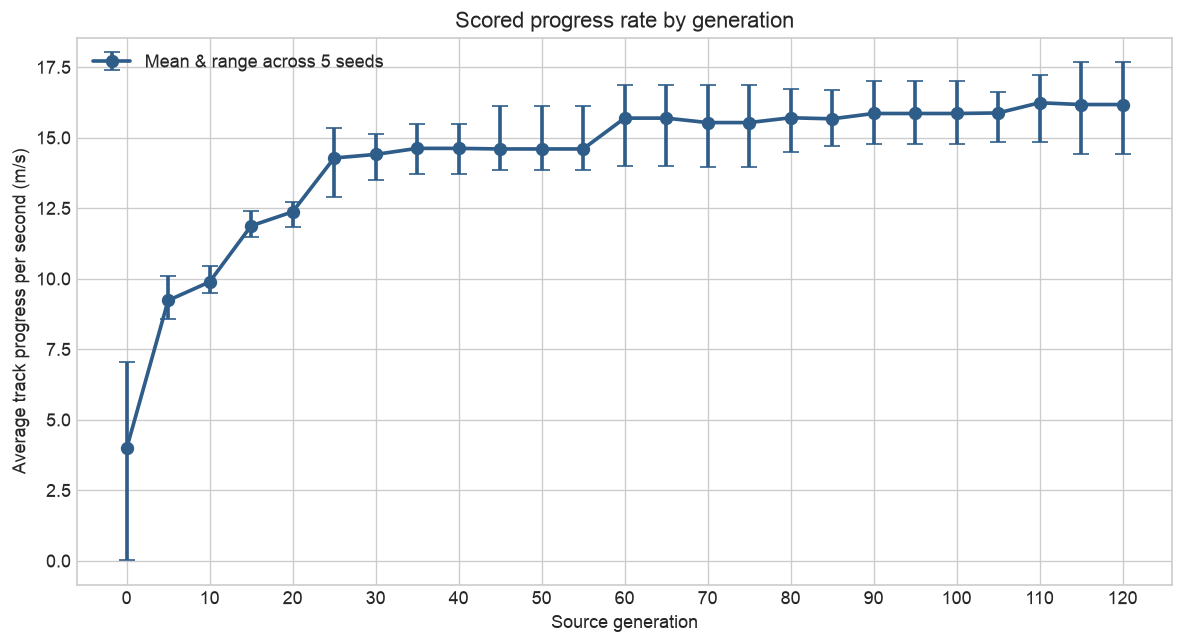

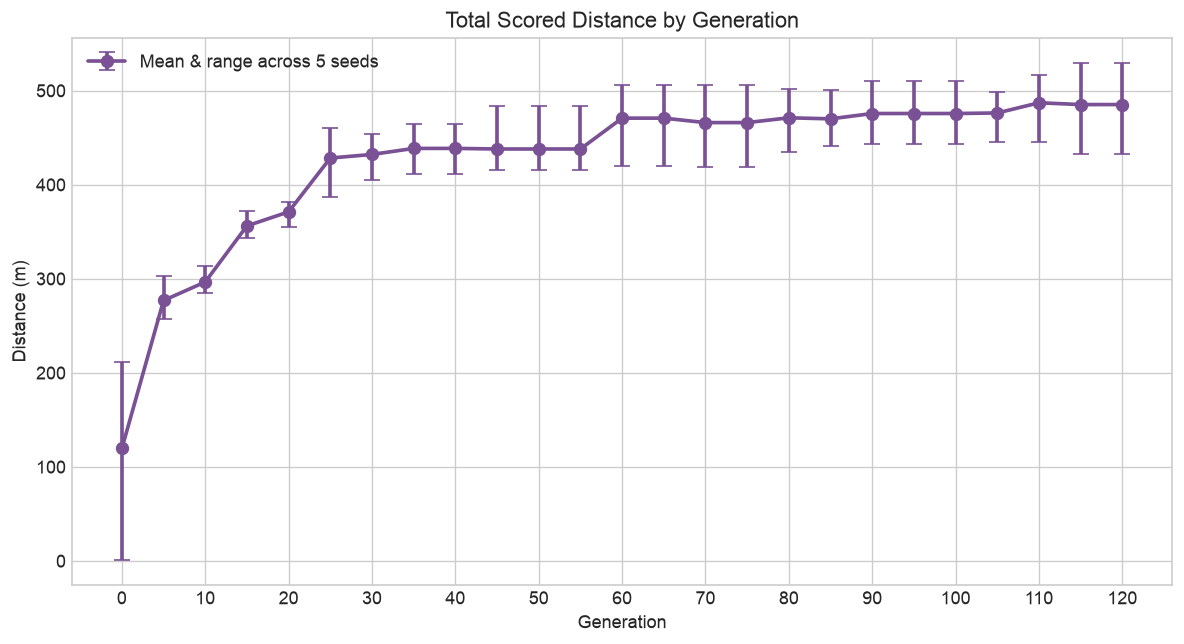

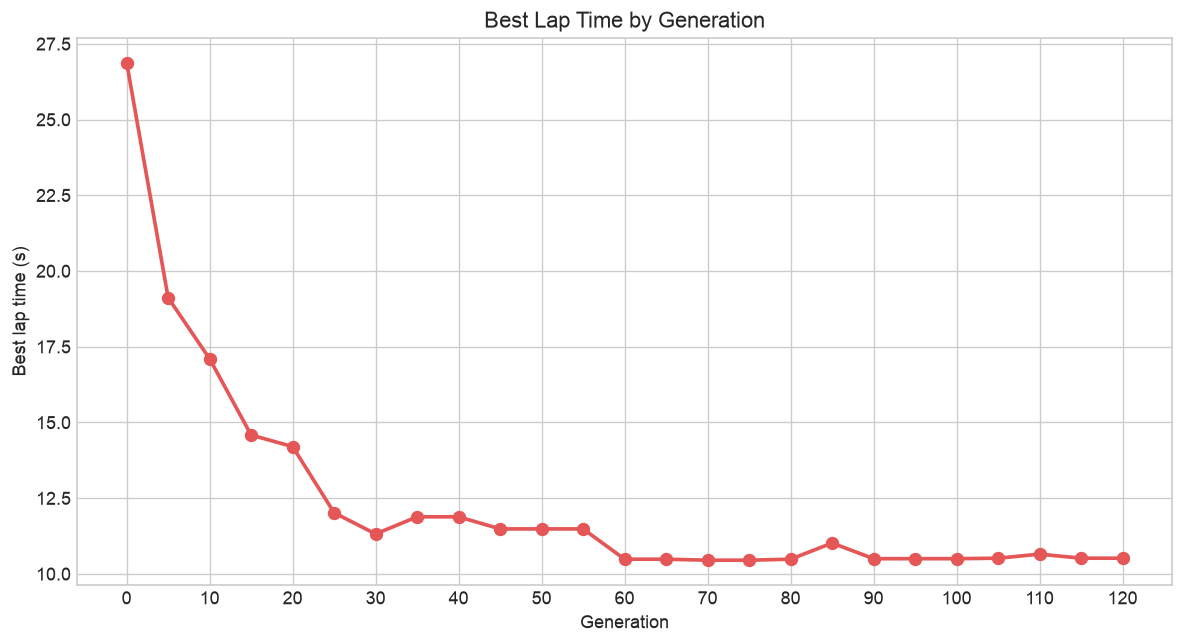

,generation,mean_scored_progress_mps,min_seed_progress_mps,max_seed_progress_mps,mean_scored_distance_m,min_seed_distance_m,max_seed_distance_m,best_lap_time_s,median_best_lap_s,lap_completion_seeds
0,0,3.984,0.025,7.042,119.534,0.747,211.266,26.883,27.383,2
1,5,9.228,8.571,10.081,276.851,257.143,302.428,19.117,19.567,5
2,10,9.886,9.500,10.461,296.571,284.999,313.841,17.100,18.717,5
3,15,11.873,11.461,12.396,356.184,343.818,371.895,14.583,15.933,5
4,20,12.370,11.835,12.721,371.096,355.038,381.638,14.200,14.767,5
5,25,14.277,12.891,15.339,428.308,386.718,460.161,12.017,13.350,5
6,30,14.404,13.507,15.129,432.120,405.196,453.862,11.317,13.150,5
7,35,14.618,13.719,15.469,438.551,411.557,464.070,11.883,12.817,5
8,40,14.618,13.719,15.469,438.551,411.557,464.070,11.883,12.817,5
9,45,14.597,13.855,16.109,437.920,415.642,483.268,11.483,12.500,5


In [10]:
rescore_records = []
for generation_result in rescore_document["generations"]:
    seed_results = generation_result["seed_results"]
    distances = [seed_result["scored_distance_m"] for seed_result in seed_results]
    rates = [
        distance / rescore_document["round_seconds"]
        for distance in distances
    ]
    lap_times = [
        seed_result["best_lap_time_s"]
        for seed_result in seed_results
        if seed_result["best_lap_time_s"] is not None
    ]
    rescore_records.append(
        {
            "generation": generation_result["generation"],
            "mean_scored_progress_mps": fmean(rates),
            "min_seed_progress_mps": min(rates),
            "max_seed_progress_mps": max(rates),
            "mean_scored_distance_m": fmean(distances),
            "min_seed_distance_m": min(distances),
            "max_seed_distance_m": max(distances),
            "best_lap_time_s": min(lap_times) if lap_times else float("nan"),
            "median_best_lap_s": median(lap_times) if lap_times else float("nan"),
            "lap_completion_seeds": sum(seed_result["lap_count"] >= 1 for seed_result in seed_results),
        }
    )

rescore_metrics = pd.DataFrame.from_records(rescore_records)
fig, ax = plt.subplots(figsize=(10, 5.5))
lower_error = rescore_metrics["mean_scored_progress_mps"] - rescore_metrics["min_seed_progress_mps"]
upper_error = rescore_metrics["max_seed_progress_mps"] - rescore_metrics["mean_scored_progress_mps"]
ax.errorbar(
    rescore_metrics["generation"],
    rescore_metrics["mean_scored_progress_mps"],
    yerr=[lower_error, upper_error],
    color="#2F5D8A", marker="o", markersize=7, linewidth=2.2, capsize=5,
    label="Mean & range across 5 seeds",
)
ax.set(
    title="Scored progress rate by generation",
    xlabel="Source generation",
    ylabel="Average track progress per second (m/s)",
)
ax.set_xticks(range(0, 121, 10))
ax.set_xticks(list(RESCORE_GENERATIONS), minor=True)
ax.legend()
fig.tight_layout()
plt.show()

fig, distance_ax = plt.subplots(figsize=(10, 5.5))
distance_lower_error = (
    rescore_metrics["mean_scored_distance_m"] - rescore_metrics["min_seed_distance_m"]
)
distance_upper_error = (
    rescore_metrics["max_seed_distance_m"] - rescore_metrics["mean_scored_distance_m"]
)
distance_ax.errorbar(
    rescore_metrics["generation"],
    rescore_metrics["mean_scored_distance_m"],
    yerr=[distance_lower_error, distance_upper_error],
    color="#7A5195", marker="o", markersize=7, linewidth=2.2, capsize=5,
    label="Mean & range across 5 seeds",
)
distance_ax.set(
    title="Total Scored Distance by Generation",
    xlabel="Generation",
    ylabel="Distance (m)",
)
distance_ax.set_xticks(range(0, 121, 10))
distance_ax.set_xticks(list(RESCORE_GENERATIONS), minor=True)
distance_ax.legend()
fig.tight_layout()
plt.show()

fig, best_lap_ax = plt.subplots(figsize=(10, 5.5))
best_lap_ax.plot(
    rescore_metrics["generation"],
    rescore_metrics["best_lap_time_s"],
    color="#E45756", marker="o", markersize=7, linewidth=2.2,
)
best_lap_ax.set(
    title="Best Lap Time by Generation",
    xlabel="Generation",
    ylabel="Best lap time (s)",
)
best_lap_ax.set_xticks(range(0, 121, 10))
best_lap_ax.set_xticks(list(RESCORE_GENERATIONS), minor=True)
fig.tight_layout()
plt.show()
display(rescore_metrics.round(3))